In [38]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import kagglehub
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import xlabel, ylabel
from rich.jupyter import display


In [31]:
#Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")
kagglehub.login()

print("Path to dataset files:", path)

Path to dataset files: /Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [73]:
print("Arquivos no dataset:", os.listdir(path))  #verifica quais arquivos estão dentro da pasta

Arquivos no dataset: ['Teen_Mental_Health_Dataset.csv']


In [74]:
rota = os.path.join('/Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1',
                    'Teen_Mental_Health_Dataset.csv')  #junta o caminho da pasta com o arquivo

In [75]:
df = pd.read_csv(rota)
df.shape  #linhas + colunas

(1200, 13)

In [81]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


# Visão Geral do Dataset

Esse Dataset estuda como o uso de redes sociais afeta a saúde mental de adolescentes. Ele inclui hábitos diários como tempo gasto em redes sociais, sono, estresse, ansiedade e atividade física.

O objetivo é entender se o uso elevado de redes sociais está relacionado a problemas como estresse, ansiedade e depressão. Os dados ajudam na análise de comportamento e na construção de modelos de machine learning para prever riscos à saúde mental.

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


- Qual é a força da correlação entre `daily_social_media_hours` e os 4 níveis de impacto (`stress_level`, `anxiety_level`, `addiction_level` e `depression_label`)?
- Como o screen_time_before_sleep atua como um multiplicador negativo na qualidade do sono (`sleep_hours`) e como isso reflete no dia seguinte?
- Adolescentes com maior taxa de `physical_activity` apresentam níveis significativamente menores de estresse ou ansiedade, mesmo mantendo alto uso de redes sociais?
- A plataforma utilizada (`platform_usage`, como TikTok vs Instagram) isola comportamentos específicos? O impacto no `academic_performance` muda de acordo com a rede escolhida?

## PRIMEIRA PERGUNTA

In [77]:
cols = ['daily_social_media_hours', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
new_df = df[cols]

#vai calcular a matriz de correlação (Correlação de Pearson)
matrix = new_df.corr()

print("Matriz de Correlação:")
print(matrix.to_markdown())

Matriz de Correlação:
|                          |   daily_social_media_hours |   stress_level |   anxiety_level |   addiction_level |   depression_label |
|:-------------------------|---------------------------:|---------------:|----------------:|------------------:|-------------------:|
| daily_social_media_hours |                  1         |    0.0306977   |       0.0278348 |      -0.0249641   |          0.175201  |
| stress_level             |                  0.0306977 |    1           |       0.0158113 |      -0.000129395 |          0.170474  |
| anxiety_level            |                  0.0278348 |    0.0158113   |       1         |       0.0311538   |          0.169566  |
| addiction_level          |                 -0.0249641 |   -0.000129395 |       0.0311538 |       1           |         -0.0139521 |
| depression_label         |                  0.175201  |    0.170474    |       0.169566  |      -0.0139521   |          1         |


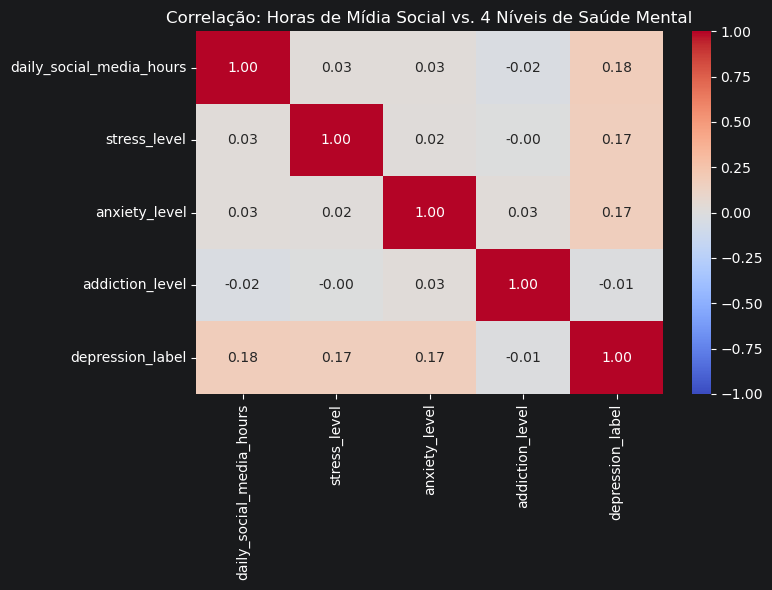

In [78]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,  # Mostra os valores numéricos em cada célula
    cmap='coolwarm',  # Esquema de cores: azul para negativo, vermelho para positivo
    vmin=-1, vmax=1,  # Fixa a escala de -1 a 1 para precisão visual
    fmt=".2f"  # Formata as casas decimais
)
plt.title('Correlação: Horas de Mídia Social vs. 4 Níveis de Saúde Mental')
plt.tight_layout()
plt.show()

Apesar da correlação ser fraca, verificamos que `depression_label` é a única que teve uma correlação maior com as horas diárias

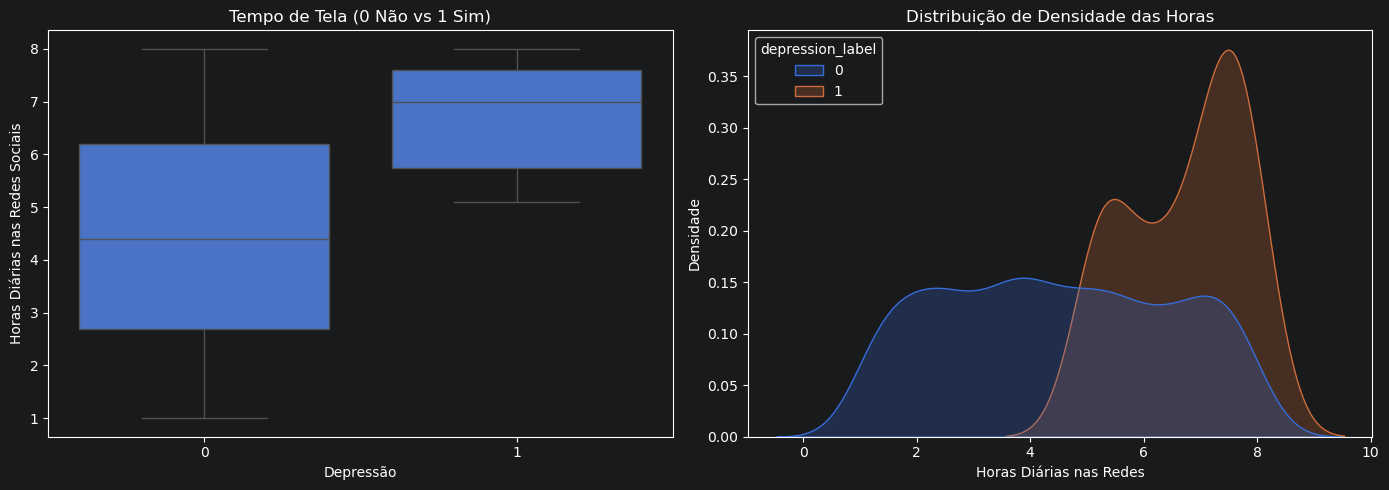

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df, ax=axes[0])
axes[0].set(title='Tempo de Tela (0 Não vs 1 Sim)', xlabel='Depressão', ylabel='Horas Diárias nas Redes Sociais')

sns.kdeplot(data=df,x='daily_social_media_hours', hue='depression_label', common_norm=False, fill=True, ax=axes[1])
axes[1].set(title='Distribuição de Densidade das Horas', xlabel='Horas Diárias nas Redes', ylabel='Densidade')

plt.tight_layout()
plt.show()

## SEGUNDA PERGUNTA

In [80]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [82]:
# 1. Calculando correlações chaves
corl_sleep = df['screen_time_before_sleep'].corr(df['sleep_hours'])
corl_academic = df['screen_time_before_sleep'].corr(df['academic_performance'])
corl_stress = df['screen_time_before_sleep'].corr(df['stress_level'])
corl_activ = df['screen_time_before_sleep'].corr(df['physical_activity'])

print(f"Correlação Tela antes de dormir vs Horas de Sono: {corl_sleep:.2f}")
print(f"Correlação Tela antes de dormir vs Performance Acadêmica: {corl_academic:.2f}")
print(f"Correlação Tela antes de dormir vs Estresse: {corl_stress:.2f}")
print(f"Correlação Tela antes de dormir vs Atividade Física: {corl_activ:.2f}")

Correlação Tela antes de dormir vs Horas de Sono: 0.01
Correlação Tela antes de dormir vs Performance Acadêmica: -0.03
Correlação Tela antes de dormir vs Estresse: -0.01
Correlação Tela antes de dormir vs Atividade Física: -0.03


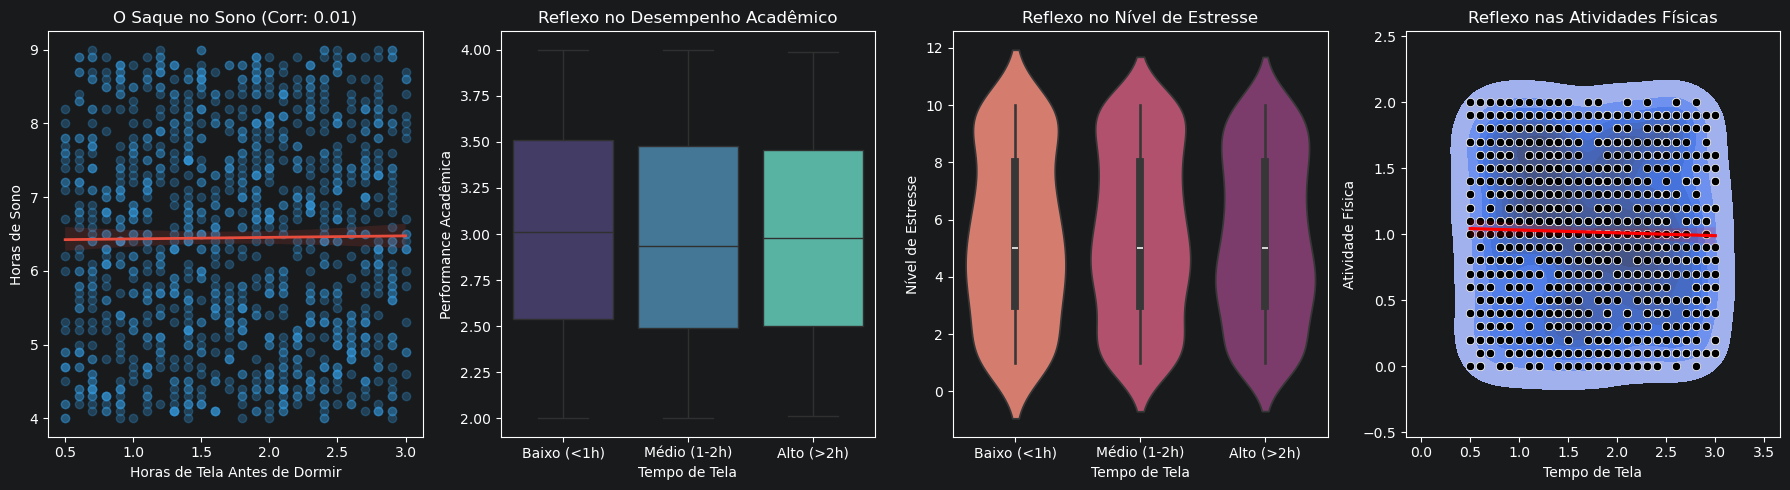

In [96]:
# Categorizando o tempo de tela antes de dormir para melhor visualização (Baixo <1h, Médio 1-2h, Alto >2h)
df['screen_time_cat'] = pd.cut(df['screen_time_before_sleep'], bins=[0, 1, 2, 5],labels=['Baixo (<1h)', 'Médio (1-2h)', 'Alto (>2h)'])

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.regplot(x='screen_time_before_sleep', y='sleep_hours', data=df,
            scatter_kws={'alpha': 0.3, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2}, ax=axes[0])
axes[0].set(title=f'O Saque no Sono (Corr: {corl_sleep:.2f})', xlabel='Horas de Tela Antes de Dormir', ylabel='Horas de Sono')

sns.boxplot(x='screen_time_cat', y='academic_performance', data=df, palette='mako', ax=axes[1])
axes[1].set(title='Reflexo no Desempenho Acadêmico', xlabel='Tempo de Tela', ylabel='Performance Acadêmica')

sns.violinplot(x='screen_time_cat', y='stress_level', data=df, palette='flare', ax=axes[2])
axes[2].set(title='Reflexo no Nível de Estresse', xlabel='Tempo de Tela', ylabel='Nível de Estresse')

sns.kdeplot(x='screen_time_before_sleep', y='physical_activity', data=df, fill=True, ax=axes[3])
sns.scatterplot(x='screen_time_before_sleep', y='physical_activity', data=df, color='black', ax=axes[3])
sns.regplot(x='screen_time_before_sleep', y='physical_activity', data=df, scatter=False, color='red')
axes[3].set(title='Reflexo nas Atividades Físicas', xlabel='Tempo de Tela', ylabel='Atividade Física')

plt.tight_layout()
plt.show()

Novamente, não há uma correlação forte suficiente entre o tempo de tela antes de dormir com qualidade do sono e não afeta significativamente no dia seguinte

## TERCEIRA PERGUNTA